# Notebook 3 - Baseline Model

This notebook develops a baseline machine learning model for predicting residential property close prices using the preprocessed CRMLS dataset.

The workflow loads the cleaned and encoded training, validation, and testing datasets, defines the prediction target, trains a pre-specified Linear Regression baseline on the combined training and validation periods, and evaluates it using MAE, MAPE, MdAPE, RMSE, and R² on the held-out test set.

The resulting performance metrics establish a baseline benchmark for comparing more advanced machine learning models in subsequent stages of the project.

## Week 4 Summary

- Loaded the cleaned and encoded training, validation, and testing datasets produced during preprocessing.
- Defined ClosePrice as the prediction target and prepared the feature matrix.
- Built a pre-specified Linear Regression baseline using the combined training and validation datasets; validation is not used for hyperparameter selection because this baseline has no tuned hyperparameters.
- Evaluated model performance on the held-out test dataset using MAE, MAPE, MdAPE, RMSE, and R².
- Summarized the target variable distribution to provide context for prediction errors.
- Established baseline performance metrics for comparison with future machine learning models.

## Setup & Load Data

In [1]:
# Data manipulation
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
# Machine Learning
from sklearn.linear_model import LinearRegression
# Evaluation
from sklearn.metrics import (r2_score, mean_absolute_error, mean_absolute_percentage_error, root_mean_squared_error)
# Plot
import matplotlib.pyplot as plt

In [2]:
# Number of historical months used for training
TRAIN_MONTHS = 30

In [3]:
# Load csv files into dataframe
data_dir = Path("../data/cleaned_full")
paths = {
    "train_encoded": data_dir / f"train_encoded_{TRAIN_MONTHS}m.csv",
    "validation_encoded": data_dir / f"validation_encoded_{TRAIN_MONTHS}m.csv",
    "test_encoded": data_dir / f"test_encoded_{TRAIN_MONTHS}m.csv",
}
dfs = {
    name: pd.read_csv(path, low_memory = False)
    for name, path in paths.items()
}
train_encoded_df = dfs["train_encoded"]
validation_encoded_df = dfs["validation_encoded"]
test_encoded_df = dfs["test_encoded"]

# Read the retained transaction periods for an exact split summary
period_source = pd.read_csv(
    data_dir / f"cleaned_crmls_{TRAIN_MONTHS}m.csv",
    usecols = ["ClosePeriod"]
)
available_periods = pd.PeriodIndex(
    period_source["ClosePeriod"].dropna().astype(str),
    freq = "M"
).unique().sort_values()
test_period = available_periods.max()
validation_period = test_period - 1
training_periods = available_periods[available_periods < validation_period]

print(
    f"Training: {training_periods.min()} to {training_periods.max()} "
    f"({len(training_periods)} months)"
)
print(f"Validation: {validation_period} (1 month)")
print(f"Test: {test_period} (1 month)")

Training: 2023-11 to 2026-04 (30 months)
Validation: 2026-05 (1 month)
Test: 2026-06 (1 month)


In [4]:
print("Training Set shape:", train_encoded_df.shape)
print("Validation Set shape:", validation_encoded_df.shape)
print("Test Set shape:", test_encoded_df.shape)

Training Set shape: (317384, 128)
Validation Set shape: (11646, 128)
Test Set shape: (12442, 128)


## Prepare Features and Target

In [5]:
# Set up target
# Linear Regression is pre-specified, so train on all pre-test observations
development_encoded_df = pd.concat(
    [train_encoded_df, validation_encoded_df],
    ignore_index = True
)
x_train = development_encoded_df.drop(columns = ["ClosePrice"])
y_train = development_encoded_df["ClosePrice"]
# Test set
x_test = test_encoded_df.drop(columns = ["ClosePrice"])
y_test = test_encoded_df["ClosePrice"]

In [6]:
print("Final Training Set (Training + Validation) shape:", x_train.shape)
print("Test Set shape:", x_test.shape)

Final Training Set (Training + Validation) shape: (329030, 127)
Test Set shape: (12442, 127)


## Final Training Target Summary (Training + Validation)

In [7]:
target_summary = y_train.describe().reset_index()
target_summary.columns = ["Statistic", "ClosePrice"]

def format_close_price(row):
    if row["Statistic"] == "count":
        return f"{row['ClosePrice']:,.0f}"
    else:
        return f"${row['ClosePrice']:,.2f}"

target_summary["ClosePrice"] = target_summary.apply(format_close_price, axis = 1)
target_summary.style.hide(axis = "index")

Statistic,ClosePrice
count,"329,030"
mean,"$1,191,566.16"
std,"$947,029.68"
min,"$189,000.00"
25%,"$621,000.00"
50%,"$889,900.00"
75%,"$1,420,000.00"
max,"$8,200,000.00"


## Train Linear Regression Model

In [8]:
# Initialize baseline model
model = LinearRegression()
model.fit(x_train, y_train)
print("Model training completed.")

Model training completed.


## Save Final Linear Regression Model

Save the fitted model and its required feature order for reuse in later notebooks.

In [9]:
model_dir = Path("../models")
model_dir.mkdir(parents = True, exist_ok = True)

joblib.dump(model, model_dir / "linear_regression.joblib")
joblib.dump(list(x_train.columns), model_dir / "model_features.joblib")

print("Saved Linear Regression model and feature schema to ../models/.")

Saved Linear Regression model and feature schema to ../models/.


## Generate Predictions

In [10]:
y_pred = model.predict(x_test)

## Evaluate Model Performance

In [11]:
def evaluation(y_test, y_pred):
    # R-squared
    r2 = r2_score(y_test, y_pred)
    # Other results
    mae = mean_absolute_error(y_test, y_pred)
    mape = mean_absolute_percentage_error(y_test, y_pred) * 100
    mdape = np.median(np.abs((y_test - y_pred) / y_test)) * 100
    rmse = root_mean_squared_error(y_test, y_pred)
    return r2, mae, mape, mdape, rmse

In [12]:
r2, mae, mape, mdape, rmse = evaluation(y_test, y_pred)

In [13]:
# Organize Results to dataframe
results = pd.DataFrame({
    "Model": ["Linear Regression"],
    "R²": [r2],
    "MAE": [mae],
    "MAPE (%)": [mape],
    "MdAPE (%)": [mdape],
    "RMSE": [rmse]
})
# Format results for display
results.style.format({
    "R²": "{:.4f}",
    "MAE": "${:,.2f}",
    "MAPE (%)": "{:.4f}%",
    "MdAPE (%)": "{:.4f}%",
    "RMSE": "${:,.2f}"
}).hide(axis = "index")

Model,R²,MAE,MAPE (%),MdAPE (%),RMSE
Linear Regression,0.6409,"$358,818.47",33.0190%,24.9885%,"$588,365.25"


## Actual vs Predicted Plot

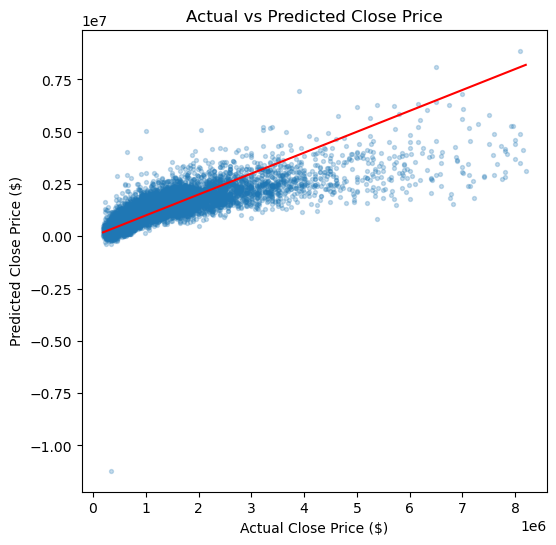

In [14]:
plt.figure(figsize = (6, 6))
plt.scatter(y_test, y_pred, alpha = 0.25, s = 8)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color = "red"
)
plt.xlabel("Actual Close Price ($)")
plt.ylabel("Predicted Close Price ($)")
plt.title("Actual vs Predicted Close Price")
plt.show()

## Evaluation Summary

### Original Evaluation Summary

The baseline Linear Regression model achieved an R² score of 0.6405 on the held-out test dataset, explaining approximately 64.05% of the variation in residential property close prices.

| Metric | Value |
|--------|------:|
| R² | 0.6405 |
| MAE | USD 368,707.93 |
| MAPE | 33.8549% |
| MdAPE | 25.1820% |
| RMSE | USD 586,081.35 |

The lower MdAPE compared with the MAPE indicates that a relatively small number of properties experienced much larger percentage prediction errors. Likewise, the RMSE being noticeably higher than the MAE suggests the presence of several large absolute prediction errors, likely associated with high-value properties.

Overall, the baseline Linear Regression model provides a useful benchmark for future comparison with more advanced machine learning models capable of capturing nonlinear relationships and complex feature interactions.

### Current Evaluation Summary

Under the chronological train/validation/test workflow, the Linear Regression model was trained on the combined training and validation periods and evaluated once on the held-out testing month. The model achieved an R² score of 0.6409, explaining approximately 64.09% of the variation in residential property close prices.

| Metric | Original | Current | Change |
|--------|---------:|--------:|:------|
| R² | 0.6405 | **0.6409** | ↑ Slightly improved |
| MAE | USD 368,707.93 | **USD 358,818.47** | ↓ Improved |
| MAPE | 33.8549% | **33.0190%** | ↓ Improved |
| MdAPE | 25.1820% | **24.9885%** | ↓ Improved |
| RMSE | USD 586,081.35 | **USD 588,365.25** | ↑ Slightly worse |

The MdAPE of 24.9885% is lower than the MAPE of 33.0190%, indicating that a minority of properties produced relatively large percentage errors and pulled the mean percentage error upward. RMSE also remained substantially higher than MAE, showing that several large dollar errors continued to affect the model, potentially among high-value or otherwise difficult-to-predict properties.

Compared with the original baseline, the current model produced a marginally higher R² and lower MAE, MAPE, and MdAPE. RMSE increased slightly, so the improvement was not uniform across all metrics and large absolute errors remain an important limitation.

Because the current experiment uses a revised chronological split, a separate validation month, combined training-plus-validation model fitting, engineered features, geographic information, and updated preprocessing rules, the difference from the original baseline should not be attributed to any single change.

These results establish the current Linear Regression baseline for comparison with Decision Tree, Random Forest, and future advanced models under the same final testing period.

---------------------------------------------------------------------------------------------------------------------------------------------------------

## Author

Jasper Fan-Chiang

M.S. in Applied Data Science
University of Southern California

IDX Exchange — Data Science Internship